In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("Train.csv")
df1=pd.read_csv("Test.csv")

df.columns = df.columns.str.strip()


print(df.shape)
print(df.columns.tolist())
df.head()

(1094, 54)
['time', 'sqNum', 'stnum', 'state_cb', 'sqDiff', 'stDiff', 'timeLastMsg', 'recentChange', 'MU1Cs', 'MU2Cs', 'MU3Cs', 'MU4Cs', 'Cs', 'consistency', 'threePhaseVSum', 'threePhaseCSum', 'threePhaseVMU1', 'MU1VoltageAngleA', 'MU1VoltageAngleB', 'MU1VoltageAngleC', 'threePhaseCurrentMU1', 'MU1CurrentAngleA', 'MU1CurrentAngleB', 'MU1CurrentAngleC', 'MU1Log', 'threePhaseVMU2', 'MU2VoltageAngleA', 'MU2VoltageAngleB', 'MU2VoltageAngleC', 'threePhaseCMU2', 'MU2CurrentAngleA', 'MU2CurrentAngleB', 'MU2CurrentAngleC', 'MU2Log', 'threePhaseVMU3', 'MU3VoltageAngleA', 'MU3VoltageAngleB', 'MU3VoltageAngleC', 'threePhaseCMU3', 'MU3CurrentAngleA', 'MU3CurrentAngleB', 'MU3CurrentAngleC', 'MU3Log', 'threePhaseVMU4', 'MU4VoltageAngleA', 'MU4VoltageAngleB', 'MU4VoltageAngleC', 'threePhaseCMU4', 'IED4_iA', 'IED4_iB', 'IED4_iC', 'MU4Log', 'any_relay', 'class']


,time,sqNum,stnum,state_cb,sqDiff,stDiff,timeLastMsg,recentChange,MU1Cs,MU2Cs,...,MU4VoltageAngleA,MU4VoltageAngleB,MU4VoltageAngleC,threePhaseCMU4,IED4_iA,IED4_iB,IED4_iC,MU4Log,any_relay,class
0,4319,1,2,1,-3,1,319,1,0,0,...,138.78,18.79,-101.19,-0.80,123.94,3.60,-115.93,0,1,Fault
1,6394,1,4,1,-1,1,75,1,0,0,...,-176.72,63.30,-56.69,-1.58,169.19,48.49,-70.63,0,1,Fault
2,7965,1,6,1,0,1,570,1,0,0,...,163.66,43.72,-76.33,0.00,0.00,0.00,0.00,1,1,Fault
3,27258,1,7,1,-19,1,293,1,0,0,...,9.53,-110.41,129.55,0.00,0.00,0.00,0.00,1,1,Fault
4,29376,1,8,1,-1,1,118,1,0,0,...,17.54,-102.43,137.57,-0.23,-2.31,-122.55,117.70,0,1,Fault


In [2876]:
print(df['class'].value_counts())

class
Normal        455
Masquerade    397
Injection     101
Replay        100
Fault          41
Name: count, dtype: int64


In [2877]:
print(df1['class'].value_counts())
df1.shape

class
Normal        455
Masquerade    397
Injection     101
Replay        100
Fault          41
Name: count, dtype: int64


(1094, 54)

In [ ]:

df = df.drop_duplicates()


print(df.isnull().sum())

df = df.fillna(0)

time                    0
sqNum                   0
stnum                   0
state_cb                0
sqDiff                  0
stDiff                  0
timeLastMsg             0
recentChange            0
MU1Cs                   0
MU2Cs                   0
MU3Cs                   0
MU4Cs                   0
Cs                      0
consistency             0
threePhaseVSum          0
threePhaseCSum          0
threePhaseVMU1          0
MU1VoltageAngleA        0
MU1VoltageAngleB        0
MU1VoltageAngleC        0
threePhaseCurrentMU1    0
MU1CurrentAngleA        0
MU1CurrentAngleB        0
MU1CurrentAngleC        0
MU1Log                  0
threePhaseVMU2          0
MU2VoltageAngleA        0
MU2VoltageAngleB        0
MU2VoltageAngleC        0
threePhaseCMU2          0
MU2CurrentAngleA        0
MU2CurrentAngleB        0
MU2CurrentAngleC        0
MU2Log                  0
threePhaseVMU3          0
MU3VoltageAngleA        0
MU3VoltageAngleB        0
MU3VoltageAngleC        0
threePhaseCM

In [2879]:
df.shape

(1094, 54)

In [2880]:
df = df.drop(columns=['time', 'sqNum'], errors='ignore')
df1 = df1.drop(columns=['time', 'sqNum'], errors='ignore')

In [ ]:
df['Vimbalance_MU1'] = df[['MU1VoltageAngleA','MU1VoltageAngleB','MU1VoltageAngleC']].std(axis=1)
df['Vimbalance_MU2'] = df[['MU2VoltageAngleA','MU2VoltageAngleB','MU2VoltageAngleC']].std(axis=1)
df['Vimbalance_MU3'] = df[['MU3VoltageAngleA','MU3VoltageAngleB','MU3VoltageAngleC']].std(axis=1)
df['Vimbalance_MU4'] = df[['MU4VoltageAngleA','MU4VoltageAngleB','MU4VoltageAngleC']].std(axis=1)

df1['Vimbalance_MU1'] = df1[['MU1VoltageAngleA','MU1VoltageAngleB','MU1VoltageAngleC']].std(axis=1)
df1['Vimbalance_MU2'] = df1[['MU2VoltageAngleA','MU2VoltageAngleB','MU2VoltageAngleC']].std(axis=1)
df1['Vimbalance_MU3'] = df1[['MU3VoltageAngleA','MU3VoltageAngleB','MU3VoltageAngleC']].std(axis=1)
df1['Vimbalance_MU4'] = df1[['MU4VoltageAngleA','MU4VoltageAngleB','MU4VoltageAngleC']].std(axis=1)

In [2882]:
df['Iimbalance_MU1'] = df[['MU1CurrentAngleA','MU1CurrentAngleB','MU1CurrentAngleC']].std(axis=1)
df['Iimbalance_MU2'] = df[['MU2CurrentAngleA','MU2CurrentAngleB','MU2CurrentAngleC']].std(axis=1)
df['Iimbalance_MU3'] = df[['MU3CurrentAngleA','MU3CurrentAngleB','MU3CurrentAngleC']].std(axis=1)
df1['Iimbalance_MU1'] = df1[['MU1CurrentAngleA','MU1CurrentAngleB','MU1CurrentAngleC']].std(axis=1)
df1['Iimbalance_MU2'] = df1[['MU2CurrentAngleA','MU2CurrentAngleB','MU2CurrentAngleC']].std(axis=1)
df1['Iimbalance_MU3'] = df1[['MU3CurrentAngleA','MU3CurrentAngleB','MU3CurrentAngleC']].std(axis=1)

In [ ]:

df['phase_diff_MU1'] = df['threePhaseVMU1'] - df['threePhaseCurrentMU1']

df['phase_diff_MU2'] = df['threePhaseVMU2'] - df['threePhaseCMU2']
df['phase_diff_MU3'] = df['threePhaseVMU3'] - df['threePhaseCMU3']
df['phase_diff_MU4'] = df['threePhaseVMU4'] - df['threePhaseCMU4']

df1['phase_diff_MU1'] = df1['threePhaseVMU1'] - df1['threePhaseCurrentMU1']
df1['phase_diff_MU2'] = df1['threePhaseVMU2'] - df1['threePhaseCMU2']
df1['phase_diff_MU3'] = df1['threePhaseVMU3'] - df1['threePhaseCMU3']
df1['phase_diff_MU4'] = df1['threePhaseVMU4'] - df1['threePhaseCMU4']

In [2884]:
df['relay_trigger'] = (df['any_relay'] > 0).astype(int)
df['change_ratio'] = df['recentChange'] / (df['timeLastMsg'] + 1)
df1['relay_trigger'] = (df1['any_relay'] > 0).astype(int)
df1['change_ratio'] = df1['recentChange'] / (df1['timeLastMsg'] + 1)

In [2885]:
df['log_sum'] = df[['MU1Log','MU2Log','MU3Log','MU4Log']].sum(axis=1)
df['log_mean'] = df[['MU1Log','MU2Log','MU3Log','MU4Log']].mean(axis=1)
df1['log_sum'] = df1[['MU1Log','MU2Log','MU3Log','MU4Log']].sum(axis=1)
df1['log_mean'] = df1[['MU1Log','MU2Log','MU3Log','MU4Log']].mean(axis=1)

In [2886]:
df['consistency_score'] = df['consistency'] * df['threePhaseVSum']
df1['consistency_score'] = df1['consistency'] * df1['threePhaseVSum']

In [2887]:
df['power_MU1'] = df['threePhaseVMU1'] * df['threePhaseCurrentMU1']
df['power_MU2'] = df['threePhaseVMU2'] * df['threePhaseCMU2']
df['power_MU3'] = df['threePhaseVMU3'] * df['threePhaseCMU3']
df['power_MU4'] = df['threePhaseVMU4'] * df['threePhaseCMU4']

df1['power_MU1'] = df1['threePhaseVMU1'] * df1['threePhaseCurrentMU1']
df1['power_MU2'] = df1['threePhaseVMU2'] * df1['threePhaseCMU2']
df1['power_MU3'] = df1['threePhaseVMU3'] * df1['threePhaseCMU3']
df1['power_MU4'] = df1['threePhaseVMU4'] * df1['threePhaseCMU4']

In [2888]:
df['angle_spread_MU1'] = df[['MU1VoltageAngleA','MU1VoltageAngleB','MU1VoltageAngleC']].max(axis=1) - df[['MU1VoltageAngleA','MU1VoltageAngleB','MU1VoltageAngleC']].min(axis=1)

df['angle_spread_MU2'] = df[['MU2VoltageAngleA','MU2VoltageAngleB','MU2VoltageAngleC']].max(axis=1) - df[['MU2VoltageAngleA','MU2VoltageAngleB','MU2VoltageAngleC']].min(axis=1)

df1['angle_spread_MU1'] = df1[['MU1VoltageAngleA','MU1VoltageAngleB','MU1VoltageAngleC']].max(axis=1) - df1[['MU1VoltageAngleA','MU1VoltageAngleB','MU1VoltageAngleC']].min(axis=1)

df1['angle_spread_MU2'] = df1[['MU2VoltageAngleA','MU2VoltageAngleB','MU2VoltageAngleC']].max(axis=1) - df1[['MU2VoltageAngleA','MU2VoltageAngleB','MU2VoltageAngleC']].min(axis=1)

In [2889]:
df['Iimbalance_MU1'] = df[['MU1CurrentAngleA','MU1CurrentAngleB','MU1CurrentAngleC']].std(axis=1)
df['Iimbalance_MU2'] = df[['MU2CurrentAngleA','MU2CurrentAngleB','MU2CurrentAngleC']].std(axis=1)
df1['Iimbalance_MU1'] = df1[['MU1CurrentAngleA','MU1CurrentAngleB','MU1CurrentAngleC']].std(axis=1)
df1['Iimbalance_MU2'] = df1[['MU2CurrentAngleA','MU2CurrentAngleB','MU2CurrentAngleC']].std(axis=1)

In [2890]:
df['relay_time'] = df['any_relay'] * df['timeLastMsg']

df1['relay_time'] = df1['any_relay'] * df1['timeLastMsg']

In [2891]:
# Your earlier engineered features (keep them)
# + add these also

df['total_voltage'] = df['threePhaseVSum']
df['total_current'] = df['threePhaseCSum']

df['V_C_ratio'] = df['threePhaseVSum'] / (df['threePhaseCSum'] + 1)

df['relay_consistency'] = df['any_relay'] * df['consistency']

df1['total_voltage'] = df1['threePhaseVSum']
df1['total_current'] = df1['threePhaseCSum']

df1['V_C_ratio'] = df1['threePhaseVSum'] / (df1['threePhaseCSum'] + 1)

df1['relay_consistency'] = df1['any_relay'] * df1['consistency']

In [2892]:
df['vc_norm_diff'] = (df['threePhaseVSum'] - df['threePhaseCSum']) / (df['threePhaseCSum'] + 1)
df1['vc_norm_diff'] = (df1['threePhaseVSum'] - df1['threePhaseCSum']) / (df1['threePhaseCSum'] + 1)

In [2893]:
for col in ['threePhaseVSum', 'threePhaseCSum', 'recentChange']:
    df[f'{col}_z'] = (df[col] - df[col].mean()) / (df[col].std() + 1)
    

for col in ['threePhaseVSum', 'threePhaseCSum', 'recentChange']:
    df1[f'{col}_z'] = (df1[col] - df1[col].mean()) / (df1[col].std() + 1)

In [2894]:
df['relative_change'] = df['recentChange'] / (df['threePhaseVSum'] + 1)
df1['relative_change'] = df1['recentChange'] / (df1['threePhaseVSum'] + 1)

In [2895]:
df['voltage_disagreement'] = df[['threePhaseVMU1','threePhaseVMU2','threePhaseVMU3','threePhaseVMU4']].std(axis=1)
df['current_disagreement'] = df[['threePhaseCurrentMU1','threePhaseCMU2','threePhaseCMU3','threePhaseCMU4']].std(axis=1)

df1['voltage_disagreement'] = df1[['threePhaseVMU1','threePhaseVMU2','threePhaseVMU3','threePhaseVMU4']].std(axis=1)
df1['current_disagreement'] = df1[['threePhaseCurrentMU1','threePhaseCMU2','threePhaseCMU3','threePhaseCMU4']].std(axis=1)

In [2896]:
df['relay_nonlin'] = df['any_relay'] * df['threePhaseVSum'] * df['recentChange']
df1['relay_nonlin'] = df1['any_relay'] * df1['threePhaseVSum'] * df1['recentChange']

In [2897]:
df['stability_score'] = df['consistency'] / (df['recentChange'] + 1)
df1['stability_score'] = df1['consistency'] / (df1['recentChange'] + 1)

In [2898]:
df['log_ratio'] = df[['MU1Log','MU2Log','MU3Log','MU4Log']].max(axis=1) / (df[['MU1Log','MU2Log','MU3Log','MU4Log']].min(axis=1) + 1)
df1['log_ratio'] = df1[['MU1Log','MU2Log','MU3Log','MU4Log']].max(axis=1) / (df1[['MU1Log','MU2Log','MU3Log','MU4Log']].min(axis=1) + 1)

In [2899]:
import numpy as np

# Select only numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Apply cleaning only on numeric columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df[num_cols] = df[num_cols].fillna(0)
df[num_cols] = df[num_cols].clip(-1e6, 1e6)

num_cols = df1.select_dtypes(include=[np.number]).columns

# Apply cleaning only on numeric columns
df1[num_cols] = df1[num_cols].replace([np.inf, -np.inf], np.nan)
df1[num_cols] = df1[num_cols].fillna(0)
df1[num_cols] = df1[num_cols].clip(-1e6, 1e6)

In [2900]:


# Time-based
df['msg_rate'] = df['recentChange'] / (df['timeLastMsg'] + 1)
df['diff_ratio'] = df['sqDiff'] / (df['stDiff'] + 1)



# Time-based
df1['msg_rate'] = df1['recentChange'] / (df1['timeLastMsg'] + 1)
df1['diff_ratio'] = df1['sqDiff'] / (df1['stDiff'] + 1)

In [2901]:
df['class'] = df['class'].apply(lambda x: 0 if x == 'Normal' else 1)
df1['class'] = df1['class'].apply(lambda x: 0 if x == 'Normal' else 1)

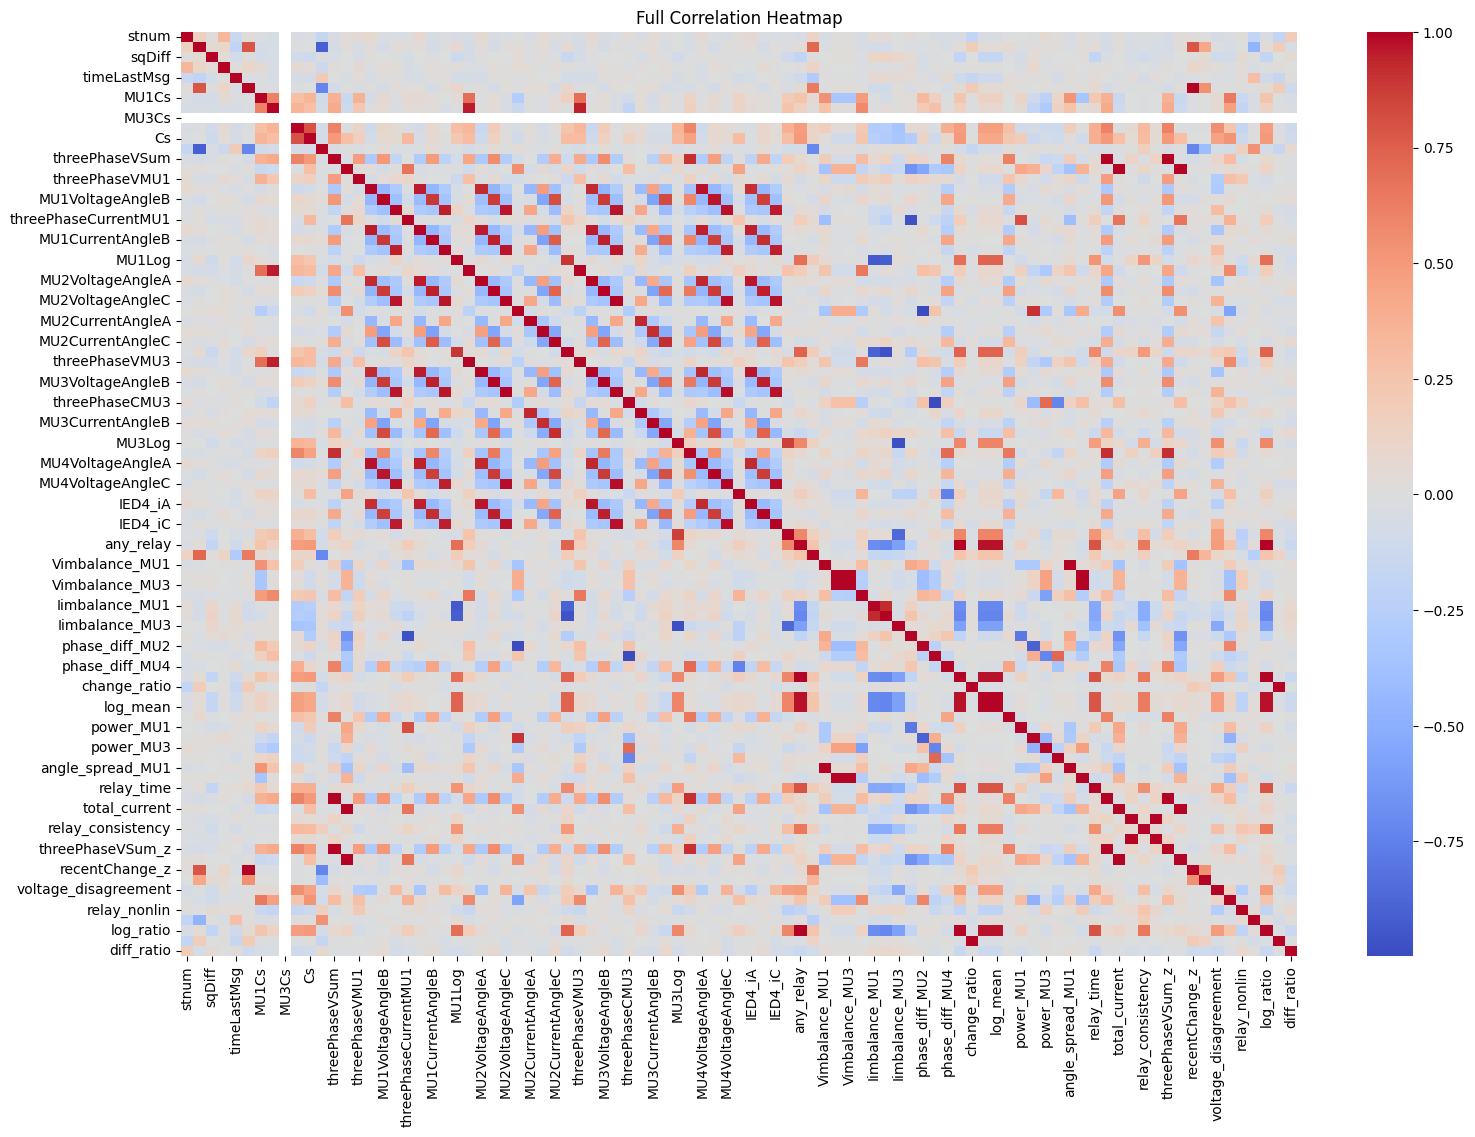

In [2902]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Full Correlation Heatmap")
plt.show()

In [2903]:
# Correlation with target
target_corr = corr['class'].abs().sort_values(ascending=False)

print(target_corr.head(40))

class                   1.000000
state_cb                0.725532
consistency             0.710240
recentChange_z          0.640863
recentChange            0.640863
relative_change         0.348207
timeLastMsg             0.294041
any_relay               0.255691
log_ratio               0.255691
relay_trigger           0.255691
stability_score         0.252940
log_sum                 0.248863
log_mean                0.248863
relay_time              0.203480
MU2Log                  0.188505
Iimbalance_MU2          0.179876
MU1Log                  0.176788
relay_consistency       0.166507
Iimbalance_MU1          0.164723
MU4Log                  0.151127
Iimbalance_MU3          0.150588
MU3Log                  0.148818
change_ratio            0.130043
msg_rate                0.130043
stnum                   0.127266
stDiff                  0.121930
Cs                      0.117380
MU4Cs                   0.110572
voltage_disagreement    0.108575
diff_ratio              0.082387
MU3Current

In [2904]:
import numpy as np

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Dropping highly correlated:", to_drop)

df = df.drop(columns=to_drop)

df1 = df1.drop(columns=to_drop)

Dropping highly correlated: ['consistency', 'MU1CurrentAngleA', 'MU1CurrentAngleC', 'threePhaseVMU2', 'MU2VoltageAngleA', 'MU2VoltageAngleB', 'MU2VoltageAngleC', 'threePhaseVMU3', 'MU3VoltageAngleA', 'MU3VoltageAngleB', 'MU3VoltageAngleC', 'MU3CurrentAngleA', 'MU3CurrentAngleB', 'MU3CurrentAngleC', 'threePhaseVMU4', 'MU4VoltageAngleA', 'MU4VoltageAngleB', 'MU4VoltageAngleC', 'IED4_iA', 'IED4_iB', 'IED4_iC', 'Vimbalance_MU3', 'Iimbalance_MU1', 'Iimbalance_MU2', 'Iimbalance_MU3', 'phase_diff_MU1', 'phase_diff_MU2', 'phase_diff_MU3', 'relay_trigger', 'log_sum', 'log_mean', 'power_MU2', 'angle_spread_MU1', 'angle_spread_MU2', 'total_voltage', 'total_current', 'vc_norm_diff', 'threePhaseVSum_z', 'threePhaseCSum_z', 'recentChange_z', 'log_ratio', 'msg_rate']


In [2905]:
df.head()

,stnum,state_cb,sqDiff,stDiff,timeLastMsg,recentChange,MU1Cs,MU2Cs,MU3Cs,MU4Cs,...,power_MU4,relay_time,V_C_ratio,relay_consistency,relative_change,voltage_disagreement,current_disagreement,relay_nonlin,stability_score,diff_ratio
0,2,1,-3,1,319,1,0,0,0,0,...,0.0720,319,0.644444,0,1.408451,0.049244,0.423035,-0.29,0.0,-1.5
1,4,1,-1,1,75,1,0,0,0,0,...,0.1580,75,0.306306,0,1.515152,0.047871,0.744821,-0.34,0.0,-0.5
2,6,1,0,1,570,1,0,0,0,0,...,-0.0000,570,-0.095745,0,1.098901,0.010000,0.030000,-0.09,0.0,0.0
3,7,1,-19,1,293,1,0,0,0,0,...,-0.0000,293,339.733333,0,-0.020016,25.611701,0.400780,-50.96,0.0,-9.5
4,8,1,-1,1,118,1,0,0,0,0,...,4.2665,118,-241.057143,0,-0.011995,31.119555,0.203039,-84.37,0.0,-0.5


In [2906]:
corr_target = df.corr()['class'].abs().sort_values(ascending=False)

print(corr_target.head(20))

# Drop weak features
low_features = corr_target[corr_target < 0.02].index
df = df.drop(columns=low_features)
df1 = df1.drop(columns=low_features)


class                   1.000000
state_cb                0.725532
recentChange            0.640863
relative_change         0.348207
timeLastMsg             0.294041
any_relay               0.255691
stability_score         0.252940
relay_time              0.203480
MU2Log                  0.188505
MU1Log                  0.176788
relay_consistency       0.166507
MU4Log                  0.151127
MU3Log                  0.148818
change_ratio            0.130043
stnum                   0.127266
stDiff                  0.121930
Cs                      0.117380
MU4Cs                   0.110572
voltage_disagreement    0.108575
diff_ratio              0.082387
Name: class, dtype: float64


In [2907]:
df.shape


(1094, 40)

In [2908]:
df1.shape

(1094, 40)

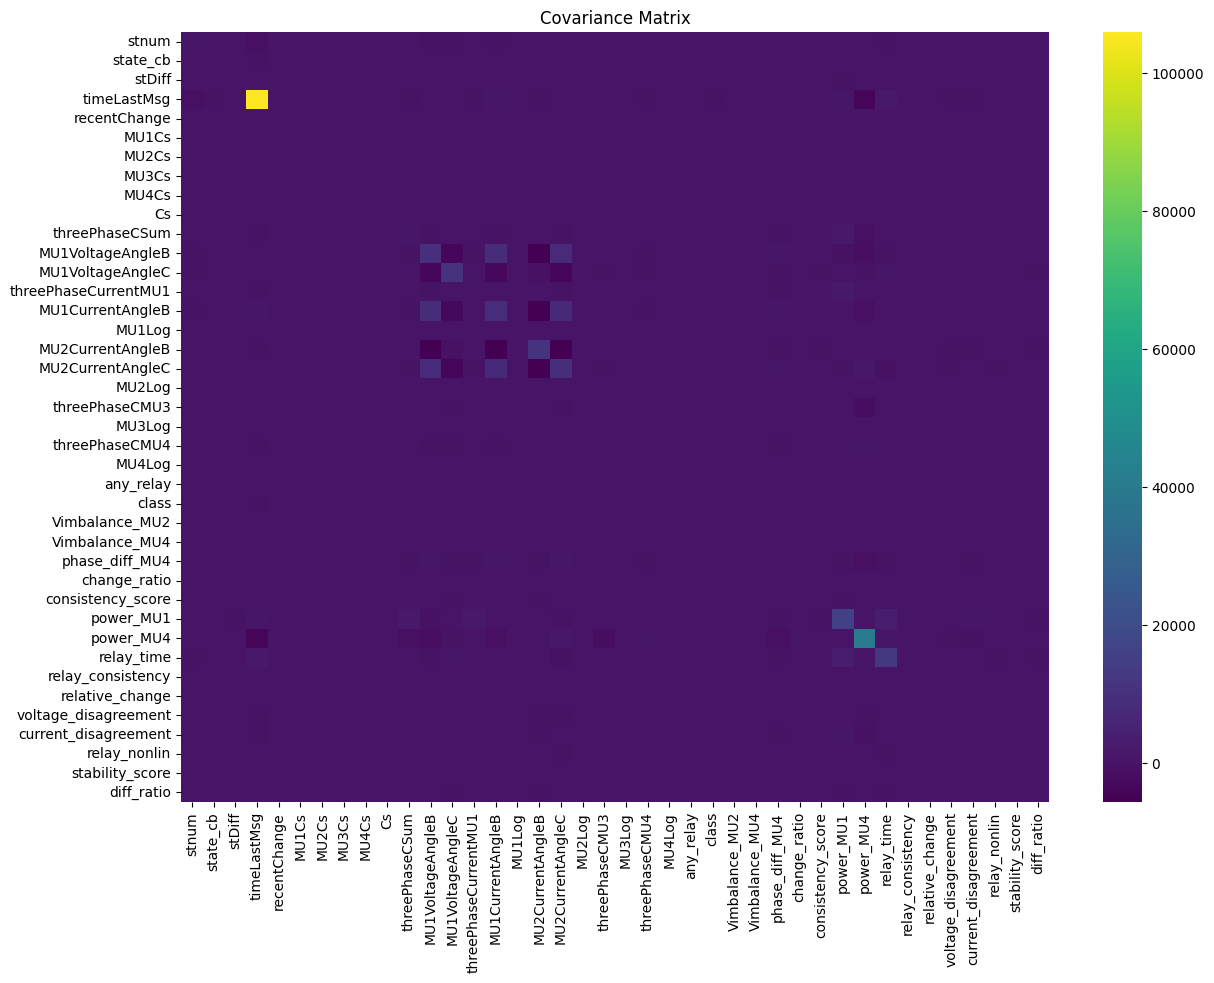

In [2909]:
cov_matrix = df.cov()

plt.figure(figsize=(14,10))
sns.heatmap(cov_matrix, cmap='viridis')
plt.title("Covariance Matrix")
plt.show()

In [2910]:
df['diff_ratio'].isnull().sum()

5

In [2911]:
df['diff_ratio'] = df['diff_ratio'].fillna(method='ffill')

C:\Users\Subhalaxmi Sahoo\AppData\Local\Temp\ipykernel_23608\2498366600.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['diff_ratio'] = df['diff_ratio'].fillna(method='ffill')


In [2912]:
corr_train = df.corr(numeric_only=True)

target_corr_train = corr_train['class'].abs().sort_values(ascending=False)

print("🔵 TRAIN CORRELATION:")
print(target_corr_train.head(20))

🔵 TRAIN CORRELATION:
class                   1.000000
state_cb                0.725532
recentChange            0.640863
relative_change         0.348207
timeLastMsg             0.294041
any_relay               0.255691
stability_score         0.252940
relay_time              0.203480
MU2Log                  0.188505
MU1Log                  0.176788
relay_consistency       0.166507
MU4Log                  0.151127
MU3Log                  0.148818
change_ratio            0.130043
stnum                   0.127266
stDiff                  0.121930
Cs                      0.117380
MU4Cs                   0.110572
voltage_disagreement    0.108575
diff_ratio              0.082184
Name: class, dtype: float64


In [2913]:
corr_test = df1.corr(numeric_only=True)

target_corr_test = corr_test['class'].abs().sort_values(ascending=False)

print("\n🟢 TEST CORRELATION:")
print(target_corr_test.head(20))


🟢 TEST CORRELATION:
class                   1.000000
stability_score         0.758450
state_cb                0.725532
timeLastMsg             0.431042
recentChange            0.259172
any_relay               0.255691
relay_time              0.218239
MU2Log                  0.188505
MU1Log                  0.176788
diff_ratio              0.172598
relay_consistency       0.166507
MU4Log                  0.151127
MU3Log                  0.148818
stnum                   0.127266
relative_change         0.118479
Cs                      0.117380
MU4Cs                   0.110572
voltage_disagreement    0.108575
change_ratio            0.100926
threePhaseCMU4          0.069348
Name: class, dtype: float64


In [2914]:
X_train = df.drop('class', axis=1)
y_train = df['class']

In [2915]:
X_test1 = df1.drop('class', axis=1)
y_test1 = df1['class']
X_test1.shape

(1094, 39)

In [2916]:
X_train.shape

(1094, 39)

In [2917]:
X_train.isnull().sum()

stnum                   0
state_cb                0
stDiff                  0
timeLastMsg             0
recentChange            0
MU1Cs                   0
MU2Cs                   0
MU3Cs                   0
MU4Cs                   0
Cs                      0
threePhaseCSum          0
MU1VoltageAngleB        0
MU1VoltageAngleC        0
threePhaseCurrentMU1    0
MU1CurrentAngleB        0
MU1Log                  0
MU2CurrentAngleB        0
MU2CurrentAngleC        0
MU2Log                  0
threePhaseCMU3          0
MU3Log                  0
threePhaseCMU4          0
MU4Log                  0
any_relay               0
Vimbalance_MU2          0
Vimbalance_MU4          0
phase_diff_MU4          0
change_ratio            0
consistency_score       0
power_MU1               0
power_MU4               0
relay_time              0
relay_consistency       0
relative_change         0
voltage_disagreement    0
current_disagreement    0
relay_nonlin            0
stability_score         0
diff_ratio  

In [ ]:
import numpy as np


X_train = X_train.replace([np.inf, -np.inf], np.nan)


X_train = X_train.fillna(0)

# Clip extreme values 
X_train = X_train.clip(-1e6, 1e6)

In [2919]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [2920]:
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel

xgb = XGBClassifier(n_estimators=200)

xgb.fit(X_train, y_train)

selector = SelectFromModel(xgb, prefit=True)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test1)

d:\conda\envs\smartgrid_gpu\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
d:\conda\envs\smartgrid_gpu\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def run_rf_cross_validation(X_train, y_train):
    
    
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=16,
        min_samples_split=4,
        min_samples_leaf=4,
        class_weight={0:1, 1:3},
        random_state=42,
        n_jobs=-1
    )

    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='recall'
    )

    
    print("\n==============================")
    print("Cross Validation Recall Scores:")
    print(scores)
    print("------------------------------")
    print("Mean Recall:", round(scores.mean(), 4))
    print("Std Dev   :", round(np.std(scores), 4))
    print("==============================\n")

    return scores.mean()

In [2922]:
mean_recall = run_rf_cross_validation(X_train, y_train)


Cross Validation Recall Scores:
[0.8671875  0.8671875  0.875      0.890625   0.96062992]
------------------------------
Mean Recall: 0.8921
Std Dev   : 0.0353



In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix

def train_rf_final(
    X_train, X_test1, y_train, y_test1,
    threshold=0.42
):
    
    
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test1 = X_test1.replace([np.inf, -np.inf], np.nan).fillna(0)

    
    for col in X_train.columns:
        if col not in X_test1.columns:
            X_test1[col] = 0

    X_test1 = X_test1[X_train.columns]

    
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=16,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight={0:1.1, 1:2.7},
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    
    y_prob = model.predict_proba(X_test1)[:, 1]
    y_prob = np.clip(y_prob, 0.01, 0.99)

    y_pred = (y_prob > threshold).astype(int)

    
    acc = accuracy_score(y_test1, y_pred)
    rec = recall_score(y_test1, y_pred)

    print("\n==============================")
    print("Threshold Used:", threshold)
    print("Accuracy:", round(acc, 4))
    print("Recall (Attack):", round(rec, 4))
    print("==============================\n")

    print("Classification Report:\n")
    print(classification_report(y_test1, y_pred))

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test1, y_pred))

    return model, threshold

In [2924]:
model, th = train_rf_final(X_train, X_test1, y_train, y_test1)


Threshold Used: 0.42
Accuracy: 0.9936
Recall (Attack): 0.9984

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       455
           1       0.99      1.00      0.99       639

    accuracy                           0.99      1094
   macro avg       0.99      0.99      0.99      1094
weighted avg       0.99      0.99      0.99      1094

Confusion Matrix:

[[449   6]
 [  1 638]]
